# **A Two-Stage Deep Learning Pipeline Using ResNet50 for Tumor Classification and ResUNet for Pixel-Level Tumor Segmentation.**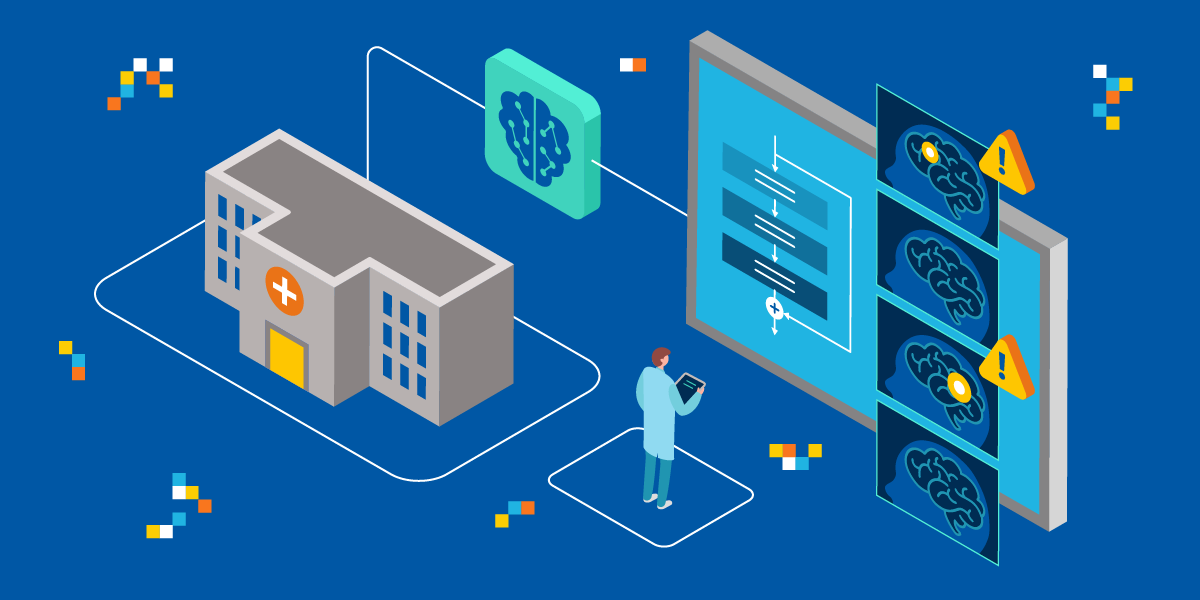

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import cv2
from skimage import io
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Model, load_model
from sklearn.model_selection import train_test_split
from tensorflow.python.keras import Sequential
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from IPython.display import display
from tensorflow.keras import backend as K
from sklearn.preprocessing import StandardScaler, normalize
from utilities import focal_tversky, tversky_loss, tversky
import os
import glob
import random
from warnings import filterwarnings
filterwarnings('ignore')
from google.colab import files
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
brain_df = pd.read_csv(
    "/content/drive/My Drive/Brain Tumor MRI Dataset/data_mask.csv"
)

brain_df.head()

,patient_id,image_path,mask_path,mask
0,TCGA_CS_5395_19981004,TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_1.tif,TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_1_...,0
1,TCGA_CS_5395_19981004,TCGA_CS_4944_20010208/TCGA_CS_4944_20010208_1.tif,TCGA_CS_4944_20010208/TCGA_CS_4944_20010208_1_...,0
2,TCGA_CS_5395_19981004,TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1.tif,TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1_...,0
3,TCGA_CS_5395_19981004,TCGA_CS_4943_20000902/TCGA_CS_4943_20000902_1.tif,TCGA_CS_4943_20000902/TCGA_CS_4943_20000902_1_...,0
4,TCGA_CS_5395_19981004,TCGA_CS_5396_20010302/TCGA_CS_5396_20010302_1.tif,TCGA_CS_5396_20010302/TCGA_CS_5396_20010302_1_...,0


In [4]:
brain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  3929 non-null   object
 1   image_path  3929 non-null   object
 2   mask_path   3929 non-null   object
 3   mask        3929 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 122.9+ KB


In [5]:
brain_df.mask_path[1] # Path to the segmentation mask

'TCGA_CS_4944_20010208/TCGA_CS_4944_20010208_1_mask.tif'

In [6]:
brain_df.image_path[1] # Path to the brain MRI image

'TCGA_CS_4944_20010208/TCGA_CS_4944_20010208_1.tif'

In [7]:
brain_df['mask'].value_counts(normalize=True) * 100

,proportion
mask,
0,65.054721
1,34.945279


In [8]:
healthy_samples = brain_df[brain_df['mask'] == 0].shape[0]

print(f"Number of healthy samples: {healthy_samples}")

Number of healthy samples: 2556


# **`Part #1: PERFORM DATA VISUALIZATION`**

In [9]:
# Calculate the number of samples in each class
class_counts = brain_df['mask'].value_counts().sort_index()

# Create an interactive bar chart
fig = go.Figure(
    data=[
        go.Bar(
            x=['Healthy', 'Tumor'],
            y=class_counts.values,
            text=class_counts.values,
            textposition='outside',
            marker_line_width=2
        )
    ]
)

# Customize the chart layout
fig.update_layout(
    title='Brain MRI Dataset Class Distribution',
    xaxis_title='Class',
    yaxis_title='Number of Samples',
    template='plotly_white',
    width=800,
    height=500
)

fig.show()

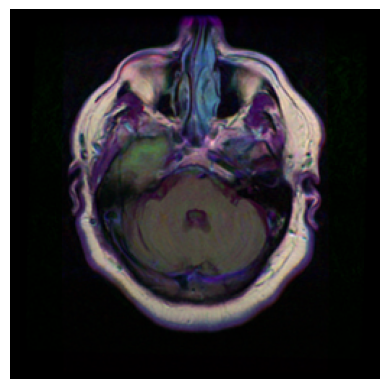

In [10]:
image_path = '/content/drive/MyDrive/Brain Tumor MRI Dataset/' + brain_df.image_path[623]

image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis('off')
plt.show()

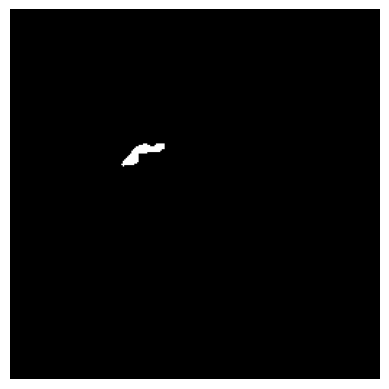

In [11]:
image_path = '/content/drive/MyDrive/Brain Tumor MRI Dataset/' + brain_df.mask_path[623]

image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis('off')
plt.show()

In [12]:
mask_path = '/content/drive/MyDrive/Brain Tumor MRI Dataset/' + brain_df.mask_path[623]
mask_image = cv2.imread(mask_path)

print(mask_image.max())
print(mask_image.min())

255
0


In [13]:
# Define the base path of the dataset
base_path = "/content/drive/MyDrive/Brain Tumor MRI Dataset"

# Convert relative paths to full paths
brain_df['image_path'] = brain_df['image_path'].apply(
    lambda x: os.path.join(base_path, x)
)

brain_df['mask_path'] = brain_df['mask_path'].apply(
    lambda x: os.path.join(base_path, x)
)

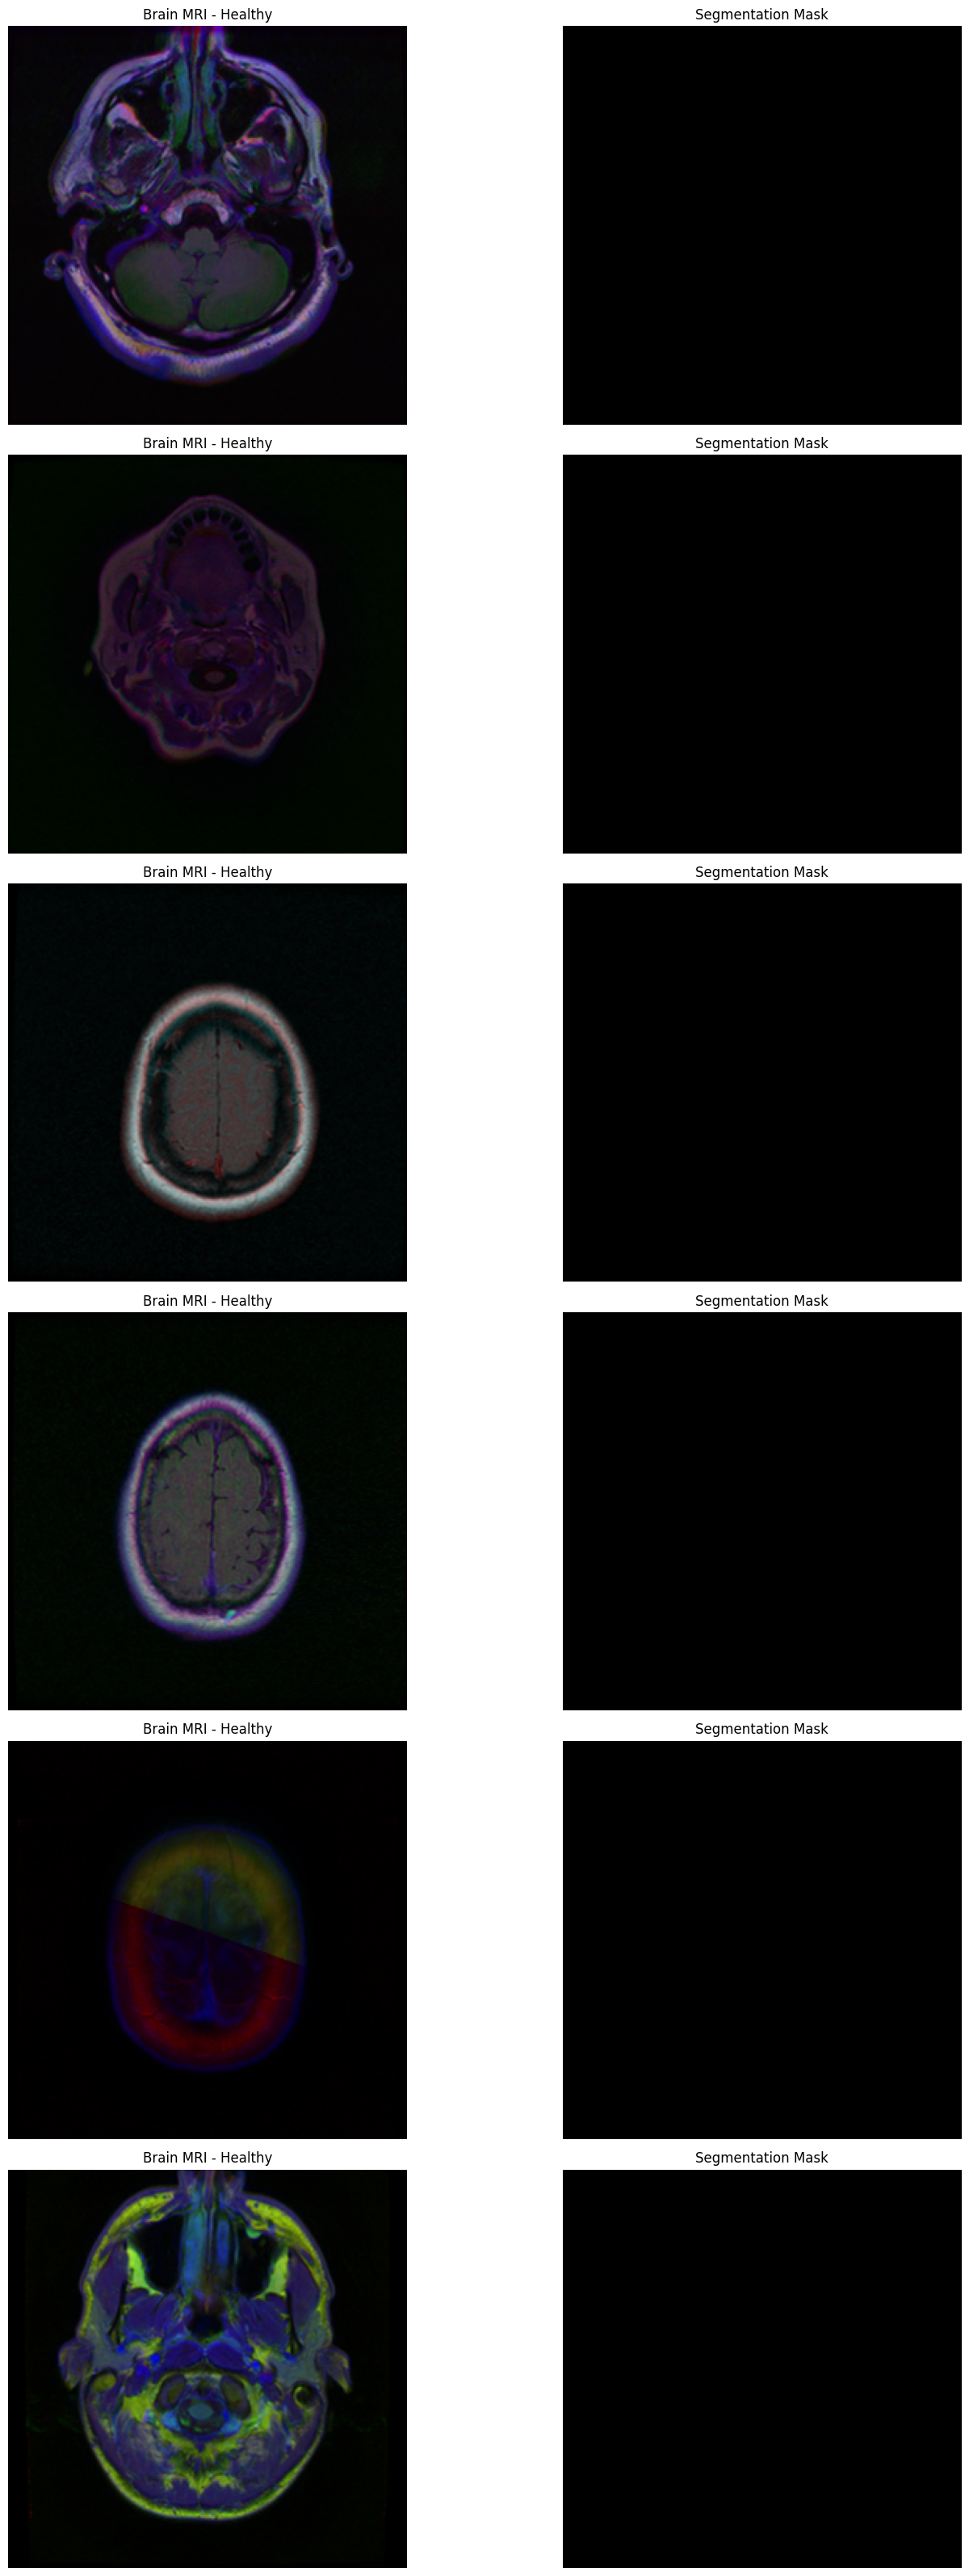

In [14]:
# Basic visualization: Visualize random MRI images and masks

fig, axs = plt.subplots(6, 2, figsize=(16, 32))

for row in range(6):

    i = random.randint(0, len(brain_df) - 1)
    image = cv2.imread(brain_df.image_path[i])
    mask_image = cv2.imread(brain_df.mask_path[i])
    label = "Healthy" if brain_df['mask'][i] == 0 else "Tumor"

    # Display the original MRI image
    axs[row, 0].set_title(f"Brain MRI - {label}")
    axs[row, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axs[row, 0].axis("off")

    # Display the segmentation mask
    axs[row, 1].set_title("Segmentation Mask")
    axs[row, 1].imshow(mask_image, cmap="gray")
    axs[row, 1].axis("off")

fig.tight_layout()
plt.show()

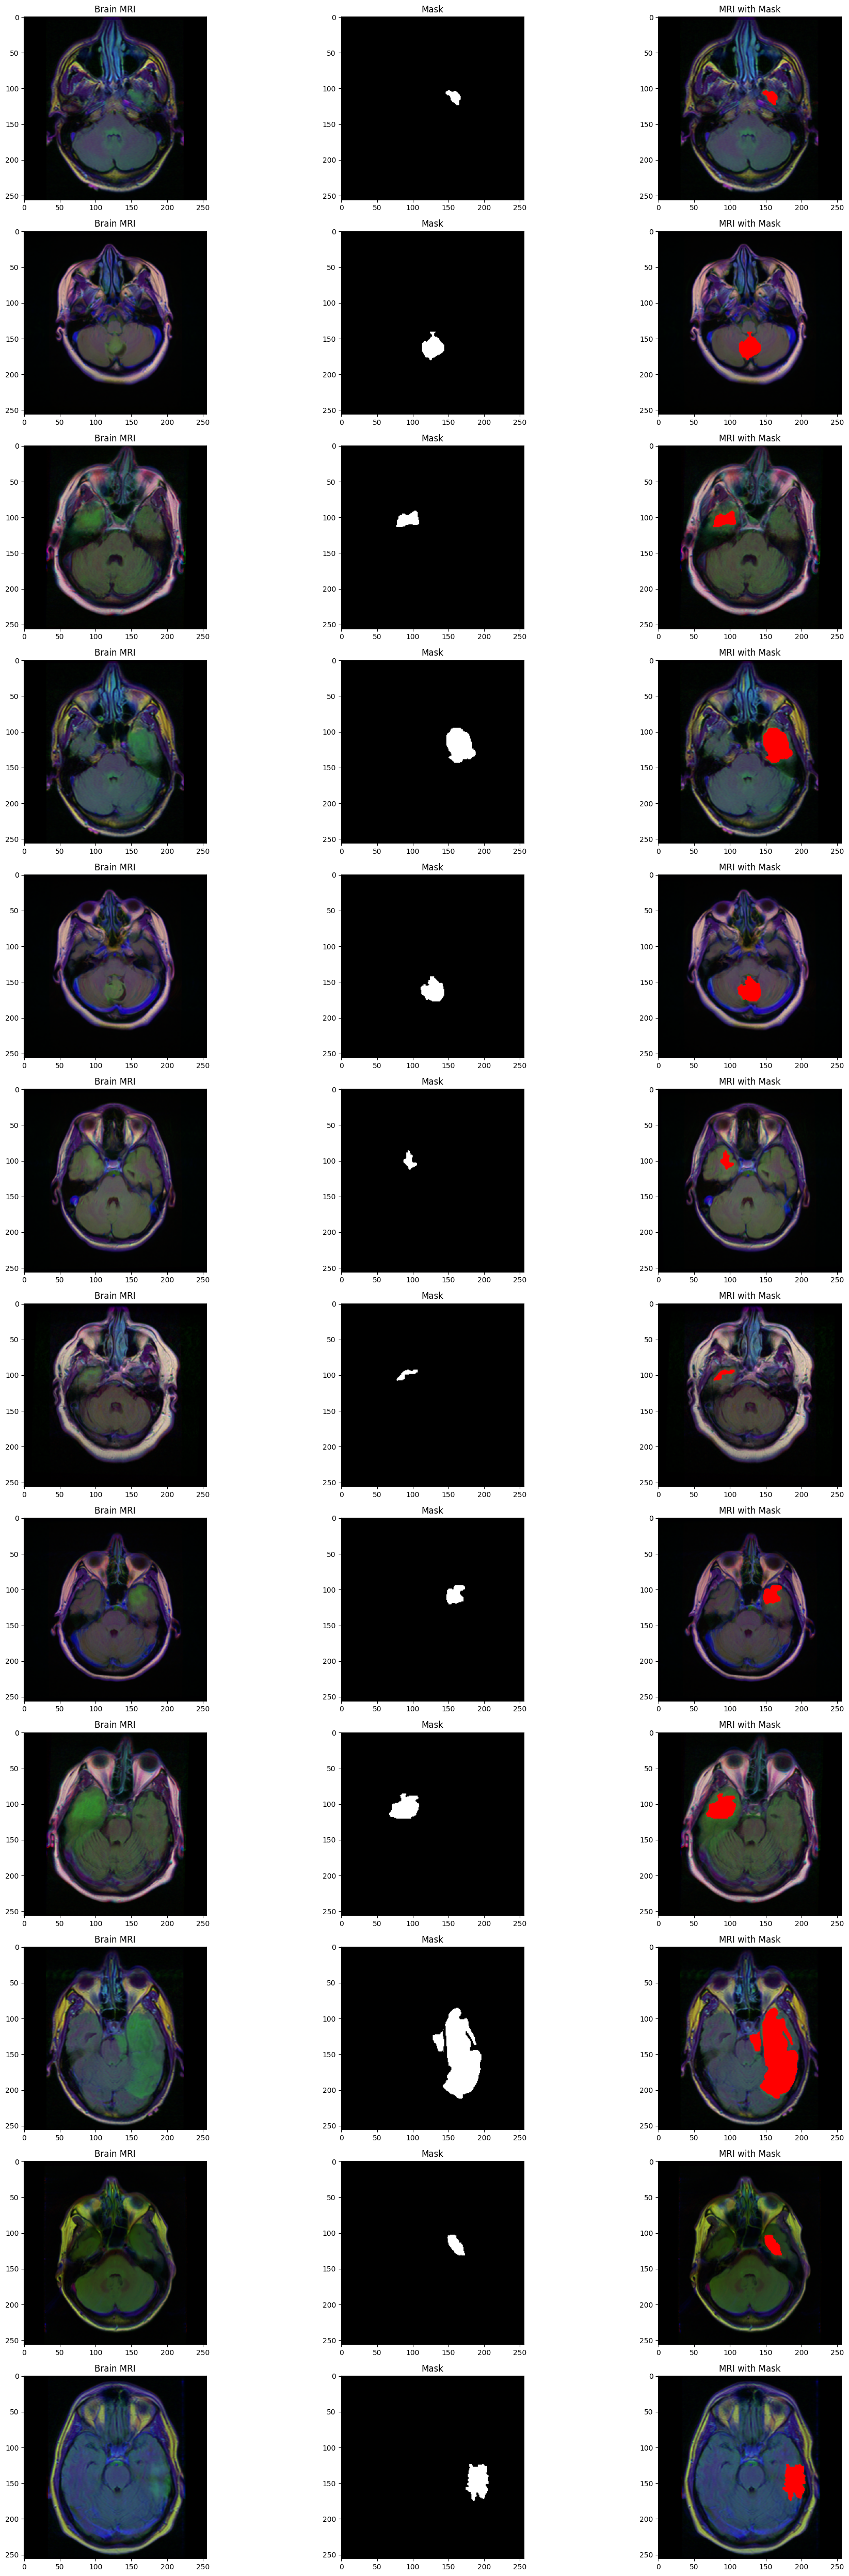

In [15]:
count = 0
fig, axs = plt.subplots(12, 3, figsize = (20, 50))
for i in range(len(brain_df)):
  if brain_df['mask'][i] ==1 and count <12:
    img = io.imread(brain_df.image_path[i])
    axs[count][0].title.set_text('Brain MRI')
    axs[count][0].imshow(img)

    mask = io.imread(brain_df.mask_path[i])
    axs[count][1].title.set_text('Mask')
    axs[count][1].imshow(mask, cmap = 'gray')


    img[mask == 255] = (255, 0, 0)
    axs[count][2].title.set_text('MRI with Mask')
    axs[count][2].imshow(img)
    count+=1

fig.tight_layout()

# **`Part #2: TRAIN A CLASSIFIER MODEL TO DETECT IF TUMOR EXISTS OR NOT`**

In [16]:
# Drop the patient id column
brain_df_train = brain_df.drop(columns = ['patient_id'])
brain_df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  3929 non-null   object
 1   mask_path   3929 non-null   object
 2   mask        3929 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 92.2+ KB


In [17]:
# Convert the data in mask column to string format, to use categorical mode in flow_from_dataframe
brain_df_train['mask'] = brain_df_train['mask'].apply(lambda x: str(x))

In [18]:
# split the data into train and test data
train, test = train_test_split(brain_df_train, test_size = 0.15)

In [19]:
# Create a data generator which scales the data from 0 to 1 and makes validation split of 0.15
datagen = ImageDataGenerator(rescale=1./255., validation_split = 0.15)

In [20]:
train_generator=datagen.flow_from_dataframe(
dataframe=train,
directory= './',
x_col='image_path',
y_col='mask',
subset="training",
batch_size=16,
shuffle=True,
class_mode="categorical",
target_size=(256,256))


valid_generator=datagen.flow_from_dataframe(
dataframe=train,
directory= './',
x_col='image_path',
y_col='mask',
subset="validation",
batch_size=16,
shuffle=True,
class_mode="categorical",
target_size=(256,256))


Found 2839 validated image filenames belonging to 2 classes.
Found 500 validated image filenames belonging to 2 classes.


In [21]:
# Create a data generator for test images

test_datagen=ImageDataGenerator(rescale=1./255.)

test_generator=test_datagen.flow_from_dataframe(
dataframe=test,
directory= './',
x_col='image_path',
y_col='mask',
batch_size=16,
shuffle=False,
class_mode='categorical',
target_size=(256,256))

Found 590 validated image filenames belonging to 2 classes.


In [22]:
# Get the ResNet50 base model
basemodel = ResNet50(weights = 'imagenet', include_top = False, input_tensor = Input(shape=(256, 256, 3)))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
basemodel.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [24]:
# freeze the model weights

for layer in basemodel.layers:
  layers.trainable = False

In [25]:
# Add classification head to the base model

headmodel = basemodel.output
headmodel = AveragePooling2D(pool_size = (4,4))(headmodel)
headmodel = Flatten(name= 'flatten')(headmodel)
headmodel = Dense(256, activation = "relu")(headmodel)
headmodel = Dropout(0.3)(headmodel)#
headmodel = Dense(256, activation = "relu")(headmodel)
headmodel = Dropout(0.3)(headmodel)
#headmodel = Dense(256, activation = "relu")(headmodel)
#headmodel = Dropout(0.3)(headmodel)
headmodel = Dense(2, activation = 'softmax')(headmodel)

model = Model(inputs = basemodel.input, outputs = headmodel)

In [26]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 25,751,426 (98.23 MB)

 Trainable params: 25,698,306 (98.03 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [27]:
# compile the model

model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics= ["accuracy"])

In [28]:
# Use early stopping to stop training if validation loss does not improve after a certain number of epochs
earlystopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=20
)

# Save the best model with the lowest validation loss
checkpoint = ModelCheckpoint(
    filepath='classifier-resnet.keras',
    verbose=1,
    save_best_only=True
)

In [29]:
history = model.fit(train_generator, steps_per_epoch= train_generator.n // 16, epochs = 2,
                    validation_data= valid_generator, validation_steps= valid_generator.n // 16, callbacks=[checkpoint, earlystopping])

Epoch 1/2
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6684 - loss: 0.9591
Epoch 1: val_loss improved from None to 2.85385, saving model to classifier-resnet.keras

Epoch 1: finished saving model to classifier-resnet.keras
177/177 ━━━━━━━━━━━━━━━━━━━━ 1303s 7s/step - accuracy: 0.6879 - loss: 0.7595 - val_accuracy: 0.3407 - val_loss: 2.8539
Epoch 2/2
  1/177 ━━━━━━━━━━━━━━━━━━━━ 45s 260ms/step - accuracy: 0.6250 - loss: 0.6579
Epoch 2: val_loss did not improve from 2.85385
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6250 - loss: 0.6579 - val_accuracy: 0.3448 - val_loss: 3.0352


In [30]:
# save the model architecture to json file for future use
model_json = model.to_json()
with open("classifier-resnet-model.json","w") as json_file:
  json_file.write(model_json)

In [31]:
# Save the complete trained model for future use
model.save("classifier-resnet.keras")

# **`Part #3: ASSESS TRAINED MODEL PERFORMANCE`**

In [45]:
import tensorflow as tf
from tensorflow.keras.models import model_from_json, Model

json_path = '/content/drive/MyDrive/Brain Tumor MRI Dataset/resnet-50-MRI.json'
weights_path = '/content/drive/MyDrive/Brain Tumor MRI Dataset/weights.hdf5'

# Read model architecture
with open(json_path, 'r') as json_file:
    json_savedModel = json_file.read()

# Rebuild model with custom object
model = model_from_json(
    json_savedModel,
    custom_objects={'Model': Model}
)

# Load pretrained weights
model.load_weights(weights_path)

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model loaded successfully!")

Model loaded successfully!


In [46]:
test_predict = model.predict(
    test_generator,
    verbose=1
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step


In [47]:
# Obtain the predicted class from the model prediction
predict = []

for i in test_predict:
  predict.append(str(np.argmax(i)))

predict = np.asarray(predict)

In [48]:
# since we have used test generator, it limited the images to len(predict), due to batch size
original = np.asarray(test['mask'])[:len(predict)]
len(original)

590

In [49]:
# Obtain the accuracy of the model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(original, predict)
accuracy

0.976271186440678

<Axes: >

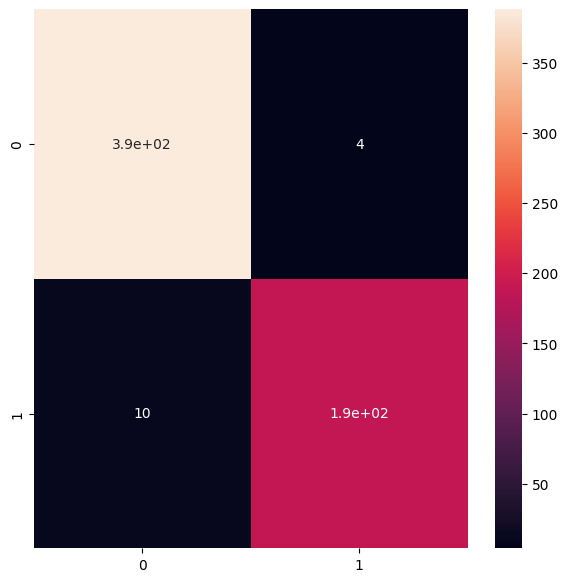

In [50]:
# plot the confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(original, predict)
plt.figure(figsize = (7,7))
sns.heatmap(cm, annot=True)

In [51]:
from sklearn.metrics import classification_report

report = classification_report(original, predict, labels = [0,1])
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       392
           1       0.98      0.95      0.96       198

   micro avg       0.98      0.98      0.98       590
   macro avg       0.98      0.97      0.97       590
weighted avg       0.98      0.98      0.98       590



# **`Part #4: BUILD A SEGMENTATION MODEL TO LOCALIZE TUMOR`**

In [52]:
# Get the dataframe containing MRIs which have masks associated with them.
brain_df_mask = brain_df[brain_df['mask'] == 1]
brain_df_mask.shape

(1373, 4)

In [53]:
# split the data into train and test data

from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(brain_df_mask, test_size=0.15)
X_test, X_val = train_test_split(X_val, test_size=0.5)

In [80]:
# Convert full paths to paths relative to /content
train_ids = [
    path.replace('/content/', '')
    for path in X_train.image_path
]

train_mask = [
    path.replace('/content/', '')
    for path in X_train.mask_path
]

val_ids = [
    path.replace('/content/', '')
    for path in X_val.image_path
]

val_mask = [
    path.replace('/content/', '')
    for path in X_val.mask_path
]

In [81]:
import sys
sys.path.append('/content/drive/MyDrive/Brain Tumor MRI Dataset')
from utilities import DataGenerator

In [82]:
training_generator = DataGenerator(train_ids,train_mask)
validation_generator = DataGenerator(val_ids,val_mask)

In [83]:
def resblock(X, f):


  # make a copy of input
  X_copy = X

  X = Conv2D(f, kernel_size = (1,1) ,strides = (1,1),kernel_initializer ='he_normal')(X)
  X = BatchNormalization()(X)
  X = Activation('relu')(X)

  X = Conv2D(f, kernel_size = (3,3), strides =(1,1), padding = 'same', kernel_initializer ='he_normal')(X)
  X = BatchNormalization()(X)

  X_copy = Conv2D(f, kernel_size = (1,1), strides =(1,1), kernel_initializer ='he_normal')(X_copy)
  X_copy = BatchNormalization()(X_copy)

  # Adding the output from main path and short path together

  X = Add()([X,X_copy])
  X = Activation('relu')(X)

  return X

In [84]:
# function to upscale and concatenate the values passsed
def upsample_concat(x, skip):
  x = UpSampling2D((2,2))(x)
  merge = Concatenate()([x, skip])

  return merge

In [85]:
input_shape = (256,256,3)

# Input tensor shape
X_input = Input(input_shape)

# Stage 1
conv1_in = Conv2D(16,3,activation= 'relu', padding = 'same', kernel_initializer ='he_normal')(X_input)
conv1_in = BatchNormalization()(conv1_in)
conv1_in = Conv2D(16,3,activation= 'relu', padding = 'same', kernel_initializer ='he_normal')(conv1_in)
conv1_in = BatchNormalization()(conv1_in)
pool_1 = MaxPool2D(pool_size = (2,2))(conv1_in)

# Stage 2
conv2_in = resblock(pool_1, 32)
pool_2 = MaxPool2D(pool_size = (2,2))(conv2_in)

# Stage 3
conv3_in = resblock(pool_2, 64)
pool_3 = MaxPool2D(pool_size = (2,2))(conv3_in)

# Stage 4
conv4_in = resblock(pool_3, 128)
pool_4 = MaxPool2D(pool_size = (2,2))(conv4_in)

# Stage 5 (Bottle Neck)
conv5_in = resblock(pool_4, 256)

# Upscale stage 1
up_1 = upsample_concat(conv5_in, conv4_in)
up_1 = resblock(up_1, 128)

# Upscale stage 2
up_2 = upsample_concat(up_1, conv3_in)
up_2 = resblock(up_2, 64)

# Upscale stage 3
up_3 = upsample_concat(up_2, conv2_in)
up_3 = resblock(up_3, 32)

# Upscale stage 4
up_4 = upsample_concat(up_3, conv1_in)
up_4 = resblock(up_4, 16)

# Final Output
output = Conv2D(1, (1,1), padding = "same", activation = "sigmoid")(up_4)

model_seg = Model(inputs = X_input, outputs = output )

In [86]:
model_seg.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 256, 256,  │        448 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 256, 256,  │      2,320 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 128, 128,  │        544 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 128, 128,  │      9,248 │ activation_16[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 128, 128,  │        544 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 128, 128,  │          0 │ add_8[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ activation_17[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 64, 64,    │      2,112 │ max_pooling2d_5[

 Total params: 1,210,513 (4.62 MB)

 Trainable params: 1,206,129 (4.60 MB)

 Non-trainable params: 4,384 (17.12 KB)

# **`Part #4: TRAIN A SEGMENTATION RESUNET MODEL TO LOCALIZE TUMOR`**

In [125]:
def tversky_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    return tversky(y_true, y_pred)


def focal_tversky_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    return focal_tversky(y_true, y_pred)

In [126]:
# Compile the model
adam = tf.keras.optimizers.Adam(learning_rate = 0.05, epsilon = 0.1)

model_seg.compile(
    optimizer=adam,
    loss=focal_tversky_loss,
    metrics=[tversky_metric]
)

In [127]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training if validation loss does not improve
earlystopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=20,
    restore_best_weights=True
)

# Save the best complete ResUNet model
checkpoint = ModelCheckpoint(
    filepath='ResUNet.keras',
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_best_only=True
)

In [128]:
history = model_seg.fit(
    training_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[checkpoint, earlystopping]
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.4001 - tversky_metric: 0.7039
Epoch 1: val_loss improved from None to 0.55576, saving model to ResUNet.keras

Epoch 1: finished saving model to ResUNet.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 223ms/step - loss: 0.3934 - tversky_metric: 0.7099 - val_loss: 0.5558 - val_tversky_metric: 0.5420
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.3581 - tversky_metric: 0.7443
Epoch 2: val_loss did not improve from 0.55576
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 173ms/step - loss: 0.3414 - tversky_metric: 0.7596 - val_loss: 0.6522 - val_tversky_metric: 0.4336
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.3017 - tversky_metric: 0.7962
Epoch 3: val_loss improved from 0.55576 to 0.32143, saving model to ResUNet.keras

Epoch 3: finished saving model to ResUNet.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 188ms/step - loss: 0.3029 - tversky_metric: 0.7953 - val_loss: 0.3214 - val_tversky_metric: 0.7792
Epoch 4/50
72/72 ━━━━━━━━━━━

In [129]:
# Save the complete trained model
model_seg.save("ResUNet.keras")

# Save model architecture as JSON
model_json = model_seg.to_json()

with open("ResUNet-model.json", "w") as json_file:
    json_file.write(model_json)

print("ResUNet model saved successfully!")

ResUNet model saved successfully!


# **`Part #5: ASSESS TRAINED SEGMENTATION RESUNET MODEL PERFORMANCE`**

In [138]:
from tensorflow.keras.models import load_model

model_seg = load_model(
    "ResUNet.keras",
    compile=False
)

In [131]:
# Create a copy of test dataframe
test_fixed = test.copy()

# Replace the incorrect path
test_fixed['image_path'] = test_fixed['image_path'].str.replace(
    '/content/content/',
    '/content/',
    regex=False
)

test_fixed['mask_path'] = test_fixed['mask_path'].str.replace(
    '/content/content/',
    '/content/',
    regex=False
)

print(test_fixed['image_path'].iloc[0])

/content/drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif


In [132]:
test_fixed = test.copy()

test_fixed['image_path'] = test_fixed['image_path'].str.replace(
    '/content/',
    '',
    regex=False
)

test_fixed['mask_path'] = test_fixed['mask_path'].str.replace(
    '/content/',
    '',
    regex=False
)

print(test_fixed['image_path'].iloc[0])

drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif


In [133]:
from utilities import prediction

image_id, mask, has_mask = prediction(
    test_fixed,
    model,
    model_seg
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━

In [134]:
# Create dataframe for predictions
df_pred = pd.DataFrame({
    'image_path': image_id,
    'predicted_mask': mask,
    'has_mask': has_mask
})

df_pred.head()

,image_path,predicted_mask,has_mask
0,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_...,"[[[[2.1027242e-07], [3.8452067e-06], [6.837042...",1
1,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_FG_...,No mask,0
2,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_CS_...,No mask,0
3,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_...,No mask,0
4,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_...,"[[[[1.8584565e-07], [3.0891586e-06], [6.832682...",1


In [141]:
# Create a copy of test and normalize image paths
test_merge = test.copy()

test_merge['image_path'] = test_merge['image_path'].str.replace(
    '/content/',
    '',
    regex=False
)

# Also remove '/content/' from mask_path in test_merge to avoid duplicate prefixes
test_merge['mask_path'] = test_merge['mask_path'].str.replace(
    '/content/',
    '',
    regex=False
)

# Merge original test data with predictions
df_pred_final = test_merge.merge(
    df_pred,
    on='image_path',
    how='inner'
)

print(df_pred_final.shape)
df_pred_final.head()

(590, 5)


,image_path,mask_path,mask,predicted_mask,has_mask
0,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_...,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_...,1,"[[[[2.1027242e-07], [3.8452067e-06], [6.837042...",1
1,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_FG_...,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_FG_...,0,No mask,0
2,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_CS_...,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_CS_...,0,No mask,0
3,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_...,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_...,0,No mask,0
4,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_...,drive/MyDrive/Brain Tumor MRI Dataset/TCGA_DU_...,1,"[[[[1.8584565e-07], [3.0891586e-06], [6.832682...",1


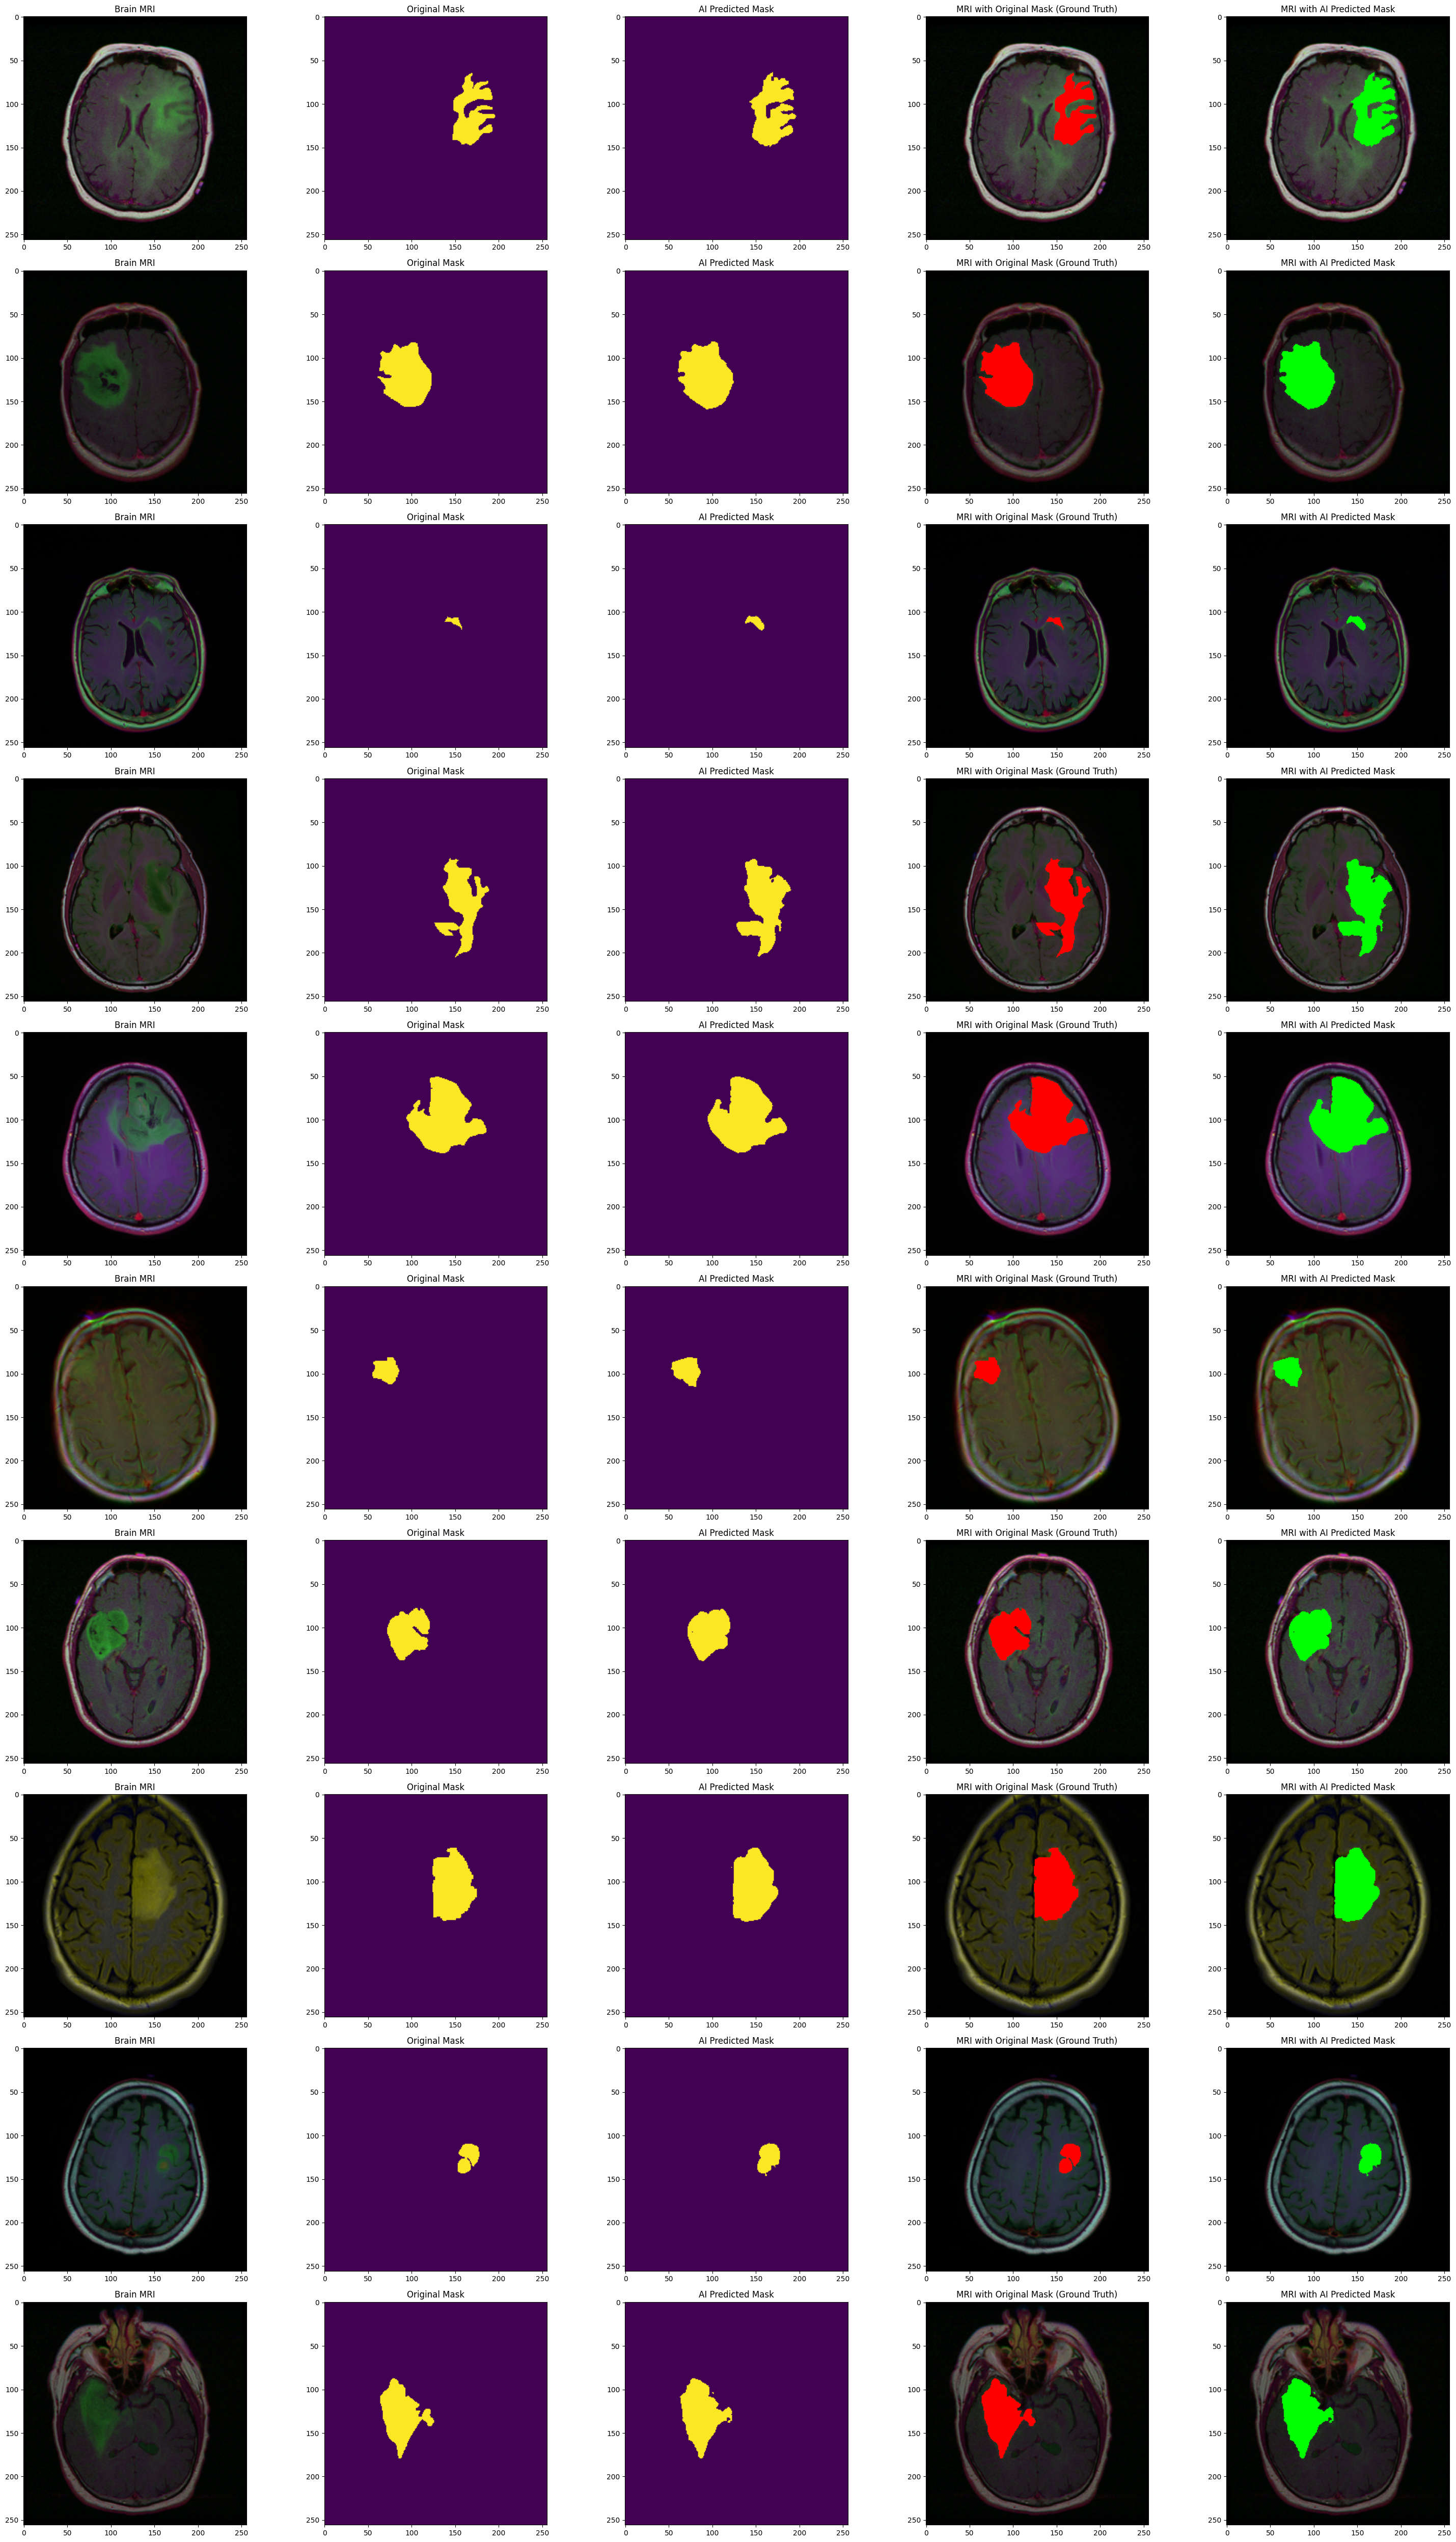

In [142]:
count = 0
fig, axs = plt.subplots(10, 5, figsize=(30, 50))
for i in range(len(df_pred_final)): # Changed to df_pred_final
  if df_pred_final['has_mask'][i] == 1 and count < 10: # Changed to df_pred_final
    # read the images and convert them to RGB format
    # Prepend '/content/' to form absolute paths
    img_path_full = '/content/' + df_pred_final.image_path[i] # Changed to df_pred_final
    img = io.imread(img_path_full)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axs[count][0].title.set_text("Brain MRI")
    axs[count][0].imshow(img)

    # Obtain the mask for the image
    # Prepend '/content/' to form absolute paths
    mask_path_full = '/content/' + df_pred_final.mask_path[i] # Changed to df_pred_final
    mask = io.imread(mask_path_full)
    axs[count][1].title.set_text("Original Mask")
    axs[count][1].imshow(mask)

    # Obtain the predicted mask for the image
    predicted_mask = np.asarray(df_pred_final.predicted_mask[i])[0].squeeze().round() # Changed to df_pred_final
    axs[count][2].title.set_text("AI Predicted Mask")
    axs[count][2].imshow(predicted_mask)

    # Apply the mask to the image 'mask==255'
    img[mask == 255] = (255, 0, 0)
    axs[count][3].title.set_text("MRI with Original Mask (Ground Truth)")
    axs[count][3].imshow(img)

    # Re-read original image for the predicted mask visualization
    img_ = io.imread(img_path_full) # Use img_path_full
    img_ = cv2.cvtColor(img_, cv2.COLOR_BGR2RGB)
    img_[predicted_mask == 1] = (0, 255, 0)
    axs[count][4].title.set_text("MRI with AI Predicted Mask")
    axs[count][4].imshow(img_)
    count += 1

fig.tight_layout()

In [143]:
print(df_pred['has_mask'].value_counts())

has_mask
0    398
1    192
Name: count, dtype: int64


In [144]:
print("Number of predicted tumor images:", (df_pred['has_mask'] == 1).sum())

Number of predicted tumor images: 192
